In [11]:
import pandas as pd
PERSON = "Fitbit_Ir"
BASE_DIR = f"cleaned_output/{PERSON}_cleaned"

In [12]:
glucose_df = pd.read_excel(
    f"{BASE_DIR}/{PERSON}_biometrics_cleaned.xlsx"
)

glucose_df["time"] = pd.to_datetime(glucose_df["time"], errors="coerce")
glucose_df = glucose_df[glucose_df["value"] > 0]  # remove reminders
glucose_df["date"] = glucose_df["time"].dt.date

glucose_df.head()


,time,value,unit,data_source,measurement_type,medical_codes,tags,source_file,days,enabled,min,max,date
0,2025-07-04 21:32:00,164,MG_DL,MANUAL,UNSPECIFIED,NaN,before bed,Glucose 202507.csv,NaN,NaN,0,0,2025-07-04
1,2025-07-04 16:08:00,150,MG_DL,MANUAL,UNSPECIFIED,14760-3:LOINC,after meal,Glucose 202507.csv,NaN,NaN,0,0,2025-07-04
2,2025-07-04 09:31:00,103,MG_DL,MANUAL,UNSPECIFIED,14760-3:LOINC,after meal,Glucose 202507.csv,NaN,NaN,0,0,2025-07-04
3,2025-07-04 06:10:00,108,MG_DL,MANUAL,UNSPECIFIED,41604-0:LOINC,fasting,Glucose 202507.csv,NaN,NaN,0,0,2025-07-04
4,2025-07-07 15:17:00,205,MG_DL,MANUAL,UNSPECIFIED,14760-3:LOINC,after meal,Glucose 202507.csv,NaN,NaN,0,0,2025-07-07


In [13]:
sleep_df = pd.read_excel(
    f"{BASE_DIR}/{PERSON}_sleep_score_cleaned.xlsx"
)

sleep_df["timestamp"] = pd.to_datetime(sleep_df["timestamp"], errors="coerce")
sleep_df["date"] = sleep_df["timestamp"].dt.date

sleep_df = sleep_df[["date", "overall_score"]]
sleep_df.head()


,date,overall_score
0,2025-07-27,65
1,2025-07-26,61
2,2025-07-25,78
3,2025-07-24,78
4,2025-07-23,69


In [ ]:
activity_df.columns


Index(['timestamp', 'heart_rate_zone', 'total_minutes', 'source_file', 'level',
       'gain', 'blood_glucose_milligrams_per_deciliter', 'measurement_source',
       'meal_type', 'measurement_timing', 'specimen', 'temperature_celsius',
       'calories', 'ratio', 'label', 'workout', 'background', 'total',
       'min_observed_load', 'max_observed_load',
       'average_heart_rate_variability_milliseconds',
       'non_rem_heart_rate_beats_per_minute', 'entropy',
       'deep_sleep_root_mean_square_of_successive_differences_milliseconds',
       'average_percentage', 'lower_bound_percentage',
       'upper_bound_percentage', 'baseline_percentage',
       'standard_deviation_percentage', 'score', 'type', 'sleep_readiness',
       'heart_rate_variability_readiness', 'resting_heart_rate_readiness',
       'breaths_per_minute', 'beats_per_minute', 'nightly_temperature_celsius',
       'baseline_temperature_celsius', 'relative_nightly_stddev_30d_celsius',
       'demographic_vo2max', 'distan

In [15]:
df = activity_df.copy()

# Convert timestamp
df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")

# Drop rows without time
df = df.dropna(subset=["timestamp"])

# Create date column
df["date"] = df["timestamp"].dt.date


In [16]:
df = df[
    (df["blood_glucose_milligrams_per_deciliter"].notna()) &
    (df["blood_glucose_milligrams_per_deciliter"] > 0)
]

df["glucose"] = df["blood_glucose_milligrams_per_deciliter"]


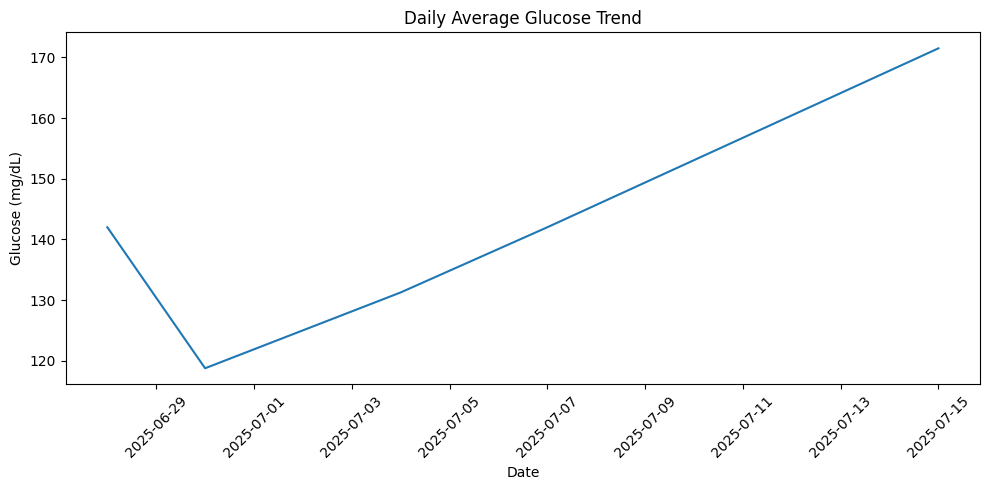

In [17]:
daily_glucose = (
    df.groupby("date")["glucose"]
    .mean()
    .reset_index()
)

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(daily_glucose["date"], daily_glucose["glucose"])
plt.title("Daily Average Glucose Trend")
plt.xlabel("Date")
plt.ylabel("Glucose (mg/dL)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [18]:
glucose_by_context = (
    df.groupby("measurement_timing")["glucose"]
    .mean()
    .reset_index()
)

glucose_by_context


,measurement_timing,glucose
0,AFTER_MEAL,143.777778
1,BEFORE_BED,151.333333
2,BEFORE_MEAL,150.000000
3,FASTING,128.000000


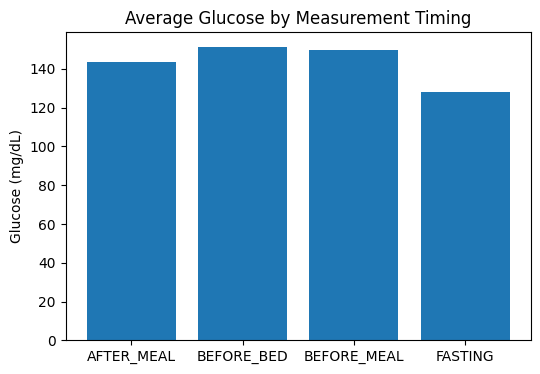

In [19]:
plt.figure(figsize=(6,4))
plt.bar(glucose_by_context["measurement_timing"], glucose_by_context["glucose"])
plt.title("Average Glucose by Measurement Timing")
plt.ylabel("Glucose (mg/dL)")
plt.show()


In [20]:
daily_activity = (
    df.groupby("date")[["steps", "calories"]]
    .sum()
    .reset_index()
)

merged = pd.merge(daily_glucose, daily_activity, on="date", how="inner")


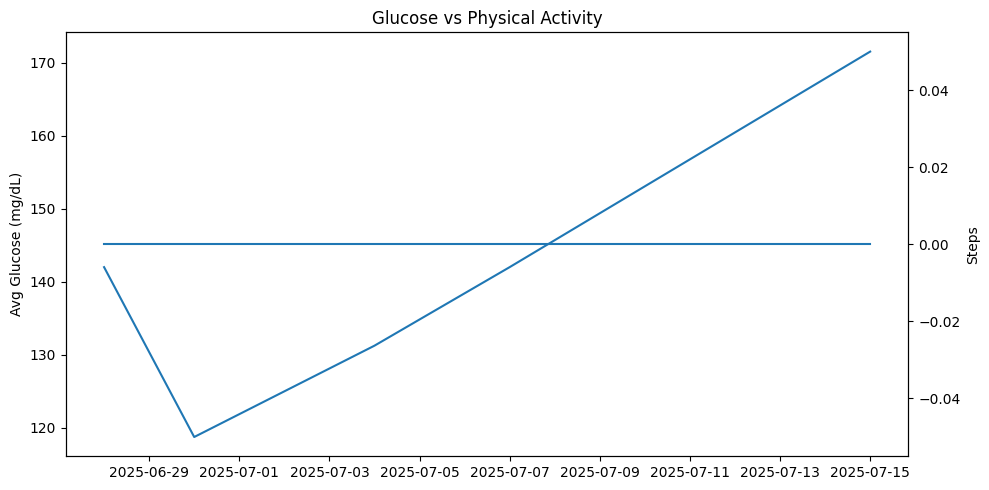

In [21]:
fig, ax1 = plt.subplots(figsize=(10,5))

ax1.plot(merged["date"], merged["glucose"])
ax1.set_ylabel("Avg Glucose (mg/dL)")

ax2 = ax1.twinx()
ax2.plot(merged["date"], merged["steps"])
ax2.set_ylabel("Steps")

plt.title("Glucose vs Physical Activity")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


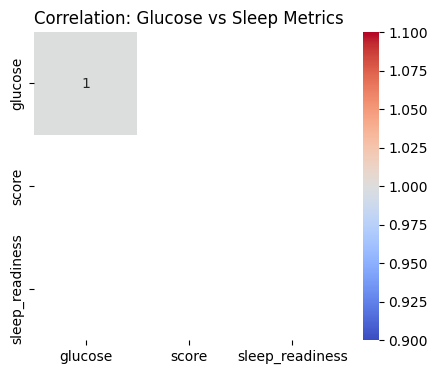

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(5,4))
sns.heatmap(
    sleep_glucose[["glucose", "score", "sleep_readiness"]].corr(),
    annot=True,
    cmap="coolwarm"
)
plt.title("Correlation: Glucose vs Sleep Metrics")
plt.show()
